In [5]:
import numpy as np
from tensorflow.keras.datasets import mnist

(x_train,y_train),(x_test,y_test) = mnist.load_data()

X_train = (x_train.astype(np.float32) / 255.0).reshape(-1, 784)
X_test  = (x_test.astype(np.float32) / 255.0).reshape(-1, 784)

def one_hot(y, num_classes=10):
    Y = np.zeros((y.size, num_classes), dtype=np.float32)
    Y[np.arange(y.size), y] = 1.0
    return Y

Y_train = one_hot(y_train, 10)
Y_test  = one_hot(y_test, 10)

def accuracy(y_true, y_pred):
    return np.mean(y_true == y_pred)


# ----------------------------
# 2) Activations + softmax
# ----------------------------
def relu(x):
    return np.maximum(0, x)

def relu_grad(x):
    # derivative of ReLU wrt its input: 1 if x>0 else 0
    return (x > 0).astype(np.float32)

def softmax(Z):
    Z_shift = Z - np.max(Z, axis=1, keepdims=True)
    expZ = np.exp(Z_shift)
    return expZ / np.sum(expZ, axis=1, keepdims=True)

def cross_entropy(P, Y):
    # small epsilon prevents log(0)
    eps = 1e-12
    return -np.mean(np.sum(Y * np.log(P + eps), axis=1))


# ----------------------------
# 3) Initialize parameters
# ----------------------------
np.random.seed(42)
N, D = X_train.shape
C = 10
H = 128  # hidden units (keep simple)

W1 = 0.01 * np.random.randn(D, H).astype(np.float32)
b1 = np.zeros((1, H), dtype=np.float32)
W2 = 0.01 * np.random.randn(H, C).astype(np.float32)
b2 = np.zeros((1, C), dtype=np.float32)


# ----------------------------
# 4) Training loop
# ----------------------------
lr = 0.1
epochs = 100
batch_size = 256

history_loss = []
history_acc = []

for epoch in range(1, epochs+1):
    perm = np.random.permutation(N)
    Xs = X_train[perm]
    Ys = Y_train[perm]
    
    for i in range(0, N, batch_size):
        Xb = Xs[i:i+batch_size]
        Yb = Ys[i:i+batch_size]
        B = Xb.shape[0]
        
        # ===== Forward pass =====
        
        # Each input image is multiplied by weights (iinitially random)
        # This produces H hidden scores per image (before activation)
        A1 = Xb @ W1 + b1          # (B, H)
        
        # Activation function: ReLU
        # Keep positive signals, kill negative ones.
        H1 = relu(A1)              # (B, H)
        
        # Second layer: from hidden to class scores
        # Input: hidden layer activations
        # Output: class scores (1 per image)
        Z2 = H1 @ W2 + b2          # (B, C)
        P  = softmax(Z2)           # (B, C)
        
        # ===== Backward pass =====
        # Softmax + cross-entropy gradient:
        dZ2 = (P - Yb) / B         # (B, C)

        dW2 = H1.T @ dZ2           # (H, C)
        db2 = np.sum(dZ2, axis=0, keepdims=True)  # (1, C)

        dH1 = dZ2 @ W2.T           # (B, H)
        dA1 = dH1 * relu_grad(A1)  # (B, H)

        dW1 = Xb.T @ dA1           # (D, H)
        db1 = np.sum(dA1, axis=0, keepdims=True)  # (1, H)

        # ===== Update =====
        W2 -= lr * dW2
        b2 -= lr * db2
        W1 -= lr * dW1
        b1 -= lr * db1
        

    # ----------------------------
    # 5) Evaluate each epoch
    # ----------------------------
    A1t = X_test @ W1 + b1
    H1t = relu(A1t)
    Z2t = H1t @ W2 + b2
    Pt  = softmax(Z2t)

    test_loss = cross_entropy(Pt, Y_test)
    y_pred = np.argmax(Pt, axis=1)
    test_acc = accuracy(y_test, y_pred)
    
    history_loss.append(test_loss)
    history_acc.append(test_acc)

    print(f"Epoch {epoch:02d}/{epochs} | test loss: {test_loss:.4f} | test acc: {test_acc:.4f}")
        


Epoch 01/100 | test loss: 0.4536 | test acc: 0.8719
Epoch 02/100 | test loss: 0.3393 | test acc: 0.9019
Epoch 03/100 | test loss: 0.2972 | test acc: 0.9163
Epoch 04/100 | test loss: 0.2665 | test acc: 0.9246
Epoch 05/100 | test loss: 0.2476 | test acc: 0.9296
Epoch 06/100 | test loss: 0.2291 | test acc: 0.9331
Epoch 07/100 | test loss: 0.2114 | test acc: 0.9400
Epoch 08/100 | test loss: 0.1959 | test acc: 0.9420
Epoch 09/100 | test loss: 0.1867 | test acc: 0.9445
Epoch 10/100 | test loss: 0.1756 | test acc: 0.9497
Epoch 11/100 | test loss: 0.1672 | test acc: 0.9507
Epoch 12/100 | test loss: 0.1574 | test acc: 0.9537
Epoch 13/100 | test loss: 0.1493 | test acc: 0.9570
Epoch 14/100 | test loss: 0.1431 | test acc: 0.9576
Epoch 15/100 | test loss: 0.1372 | test acc: 0.9580
Epoch 16/100 | test loss: 0.1315 | test acc: 0.9610
Epoch 17/100 | test loss: 0.1294 | test acc: 0.9613
Epoch 18/100 | test loss: 0.1257 | test acc: 0.9636
Epoch 19/100 | test loss: 0.1210 | test acc: 0.9646
Epoch 20/100

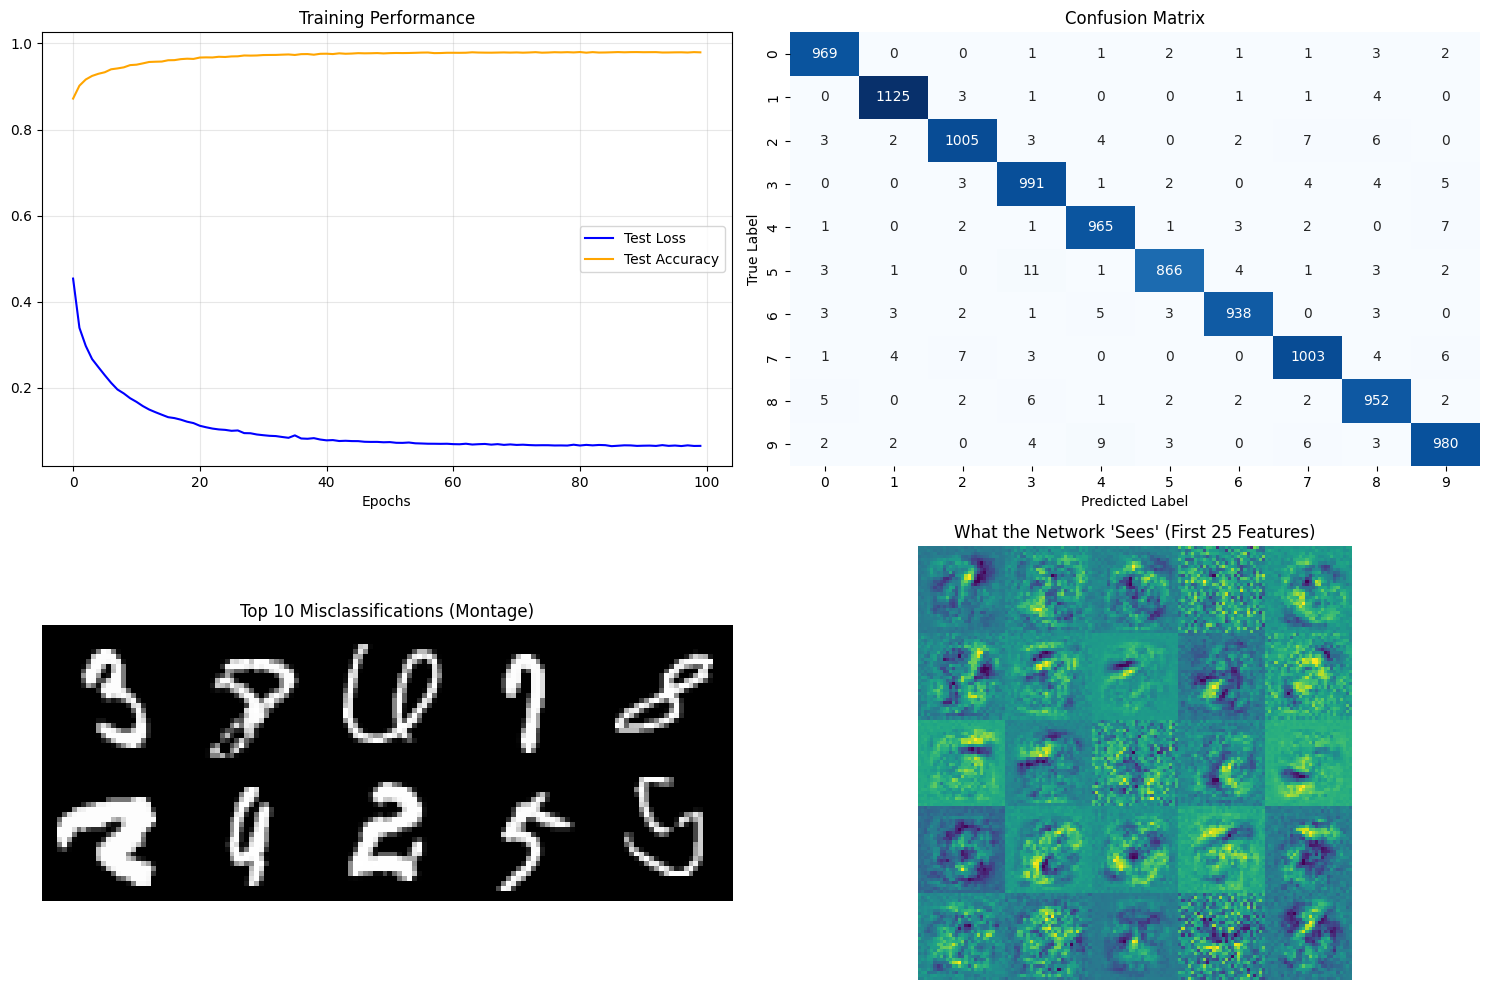

In [7]:
# ----------------------------
# 6) Visualizations (Fixed)
# ----------------------------
plt.figure(figsize=(15, 10))

# --- Plot 1: Loss over Epochs ---
plt.subplot(2, 2, 1)
plt.plot(history_loss, label='Test Loss', color='blue')
plt.plot(history_acc, label='Test Accuracy', color='orange')
plt.title("Training Performance")
plt.xlabel("Epochs")
plt.legend()
plt.grid(True, alpha=0.3)

# --- Plot 2: Confusion Matrix ---
plt.subplot(2, 2, 2)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

# --- Plot 3: Misclassified Examples (Montage Method) ---
plt.subplot(2, 2, 3)
mistakes = np.where(y_pred != y_test)[0]
if len(mistakes) > 10:
    random_mistakes = np.random.choice(mistakes, 10, replace=False)
else:
    random_mistakes = mistakes

# Create a blank canvas for 2 rows x 5 columns of images
# Each image is 28x28 pixels
canvas_misclass = np.zeros((28 * 2, 28 * 5))

for i, idx in enumerate(random_mistakes):
    row = i // 5  # 0 or 1
    col = i % 5   # 0 to 4
    img = X_test[idx].reshape(28, 28)
    # Copy image into the canvas
    canvas_misclass[row*28 : (row+1)*28, col*28 : (col+1)*28] = img

plt.imshow(canvas_misclass, cmap='gray')
plt.title("Top 10 Misclassifications (Montage)")
plt.axis('off')

# --- Plot 4: Hidden Layer Weights (Montage Method) ---
plt.subplot(2, 2, 4)

# We want to show 25 weights in a 5x5 grid
n_rows, n_cols = 5, 5
canvas_weights = np.zeros((28 * n_rows, 28 * n_cols))

for i in range(n_rows * n_cols):
    row = i // n_cols
    col = i % n_cols
    
    # Get the i-th weight column and reshape
    weight = W1[:, i].reshape(28, 28)
    
    # Normalize weight to 0-1 range for clear display
    weight = (weight - weight.min()) / (weight.max() - weight.min())
    
    # Copy into canvas
    canvas_weights[row*28 : (row+1)*28, col*28 : (col+1)*28] = weight

plt.imshow(canvas_weights, cmap='viridis')
plt.title("What the Network 'Sees' (First 25 Features)")
plt.axis('off')

plt.tight_layout()
plt.show()